In [1]:
import pandas as pd

In [2]:
aggregate_network_nci = pd.read_csv('/12tb_dsk2/danish/GRN_new_21_feb_2025/data_preprocessed/grn_output/ad_nci_seperate_network/panda/output_panda_nci_csv.csv') 

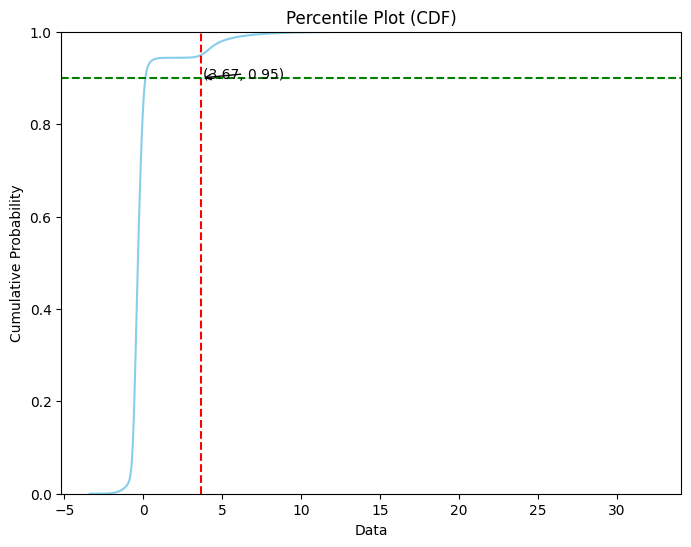

In [3]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
# Set the plot size
plt.figure(figsize=(8, 6))

# Plot percentile plot using seaborn
sns.ecdfplot(aggregate_network_nci['force'], color='skyblue')


percentile_95 = np.percentile(aggregate_network_nci['force'], 95)

plt.axvline(x=percentile_95, color='red', linestyle='--', label='90th Percentile')
plt.axhline(y=0.9, color='green', linestyle='--')

# Annotate the point on the plot
plt.annotate(f'({percentile_95:.2f}, 0.95)', xy=(percentile_95, 0.9), xytext=(percentile_95 + 0.1, 0.9),
             arrowprops=dict(facecolor='black', arrowstyle='->'))
# Display the plot
plt.title('Percentile Plot (CDF)')
plt.xlabel('Data')
plt.ylabel('Cumulative Probability')
plt.savefig("./../../../data_preprocessed/grn_analysis_output/plots/nci_cumulative.svg", format="svg", dpi=600)
plt.show()

In [4]:
aggregate_network_ad = pd.read_csv('/12tb_dsk2/danish/GRN_new_21_feb_2025/data_preprocessed/grn_output/ad_nci_seperate_network/panda/output_panda_ad_csv.csv') 

In [5]:
aggregate_network_ad 

,tf,gene,motif,force
0,ENSG00000153879,ENSG00000153132,1.0,32.263850
1,ENSG00000221869,ENSG00000153132,1.0,32.133680
2,ENSG00000153879,ENSG00000130770,1.0,32.099446
3,ENSG00000221869,ENSG00000130770,1.0,31.962409
4,ENSG00000172216,ENSG00000042980,1.0,31.823751
...,...,...,...,...
12390945,ENSG00000180855,ENSG00000092148,0.0,-2.922488
12390946,ENSG00000180855,ENSG00000105983,0.0,-2.931945
12390947,ENSG00000197841,ENSG00000153823,0.0,-2.932386
12390948,ENSG00000162714,ENSG00000153823,0.0,-2.952556


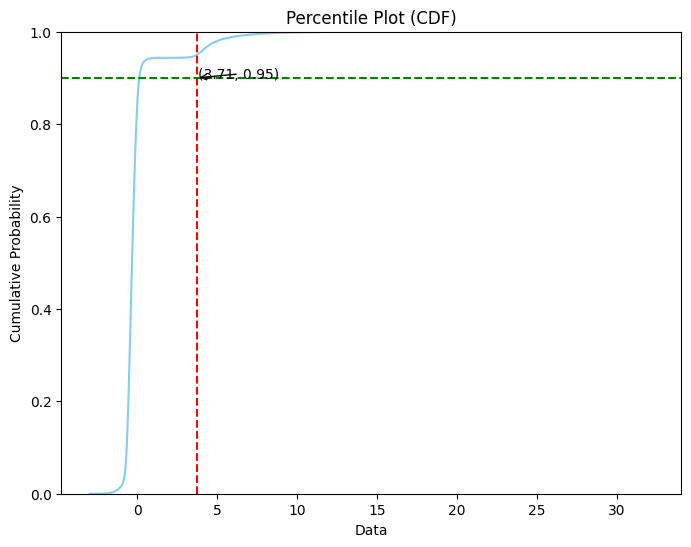

In [6]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
# Set the plot size
plt.figure(figsize=(8, 6))

# Plot percentile plot using seaborn
sns.ecdfplot(aggregate_network_ad['force'], color='skyblue')


percentile_95 = np.percentile(aggregate_network_ad['force'], 95)

plt.axvline(x=percentile_95, color='red', linestyle='--', label='90th Percentile')
plt.axhline(y=0.9, color='green', linestyle='--')

# Annotate the point on the plot
plt.annotate(f'({percentile_95:.2f}, 0.95)', xy=(percentile_95, 0.9), xytext=(percentile_95 + 0.1, 0.9),
             arrowprops=dict(facecolor='black', arrowstyle='->'))
# Display the plot
plt.title('Percentile Plot (CDF)')
plt.xlabel('Data')
plt.ylabel('Cumulative Probability')
plt.savefig("./../../../data_preprocessed/grn_analysis_output/plots/ad_cumulative.svg", format="svg", dpi=600)
plt.show()

In [10]:
aggregate_network_ad  = aggregate_network_ad[aggregate_network_ad.force>=3.71]
aggregate_network_ad 

,tf,gene,motif,force
0,ENSG00000153879,ENSG00000153132,1.0,32.263850
1,ENSG00000221869,ENSG00000153132,1.0,32.133680
2,ENSG00000153879,ENSG00000130770,1.0,32.099446
3,ENSG00000221869,ENSG00000130770,1.0,31.962409
4,ENSG00000172216,ENSG00000042980,1.0,31.823751
...,...,...,...,...
619654,ENSG00000162702,ENSG00000167565,1.0,3.710023
619655,ENSG00000146587,ENSG00000108298,1.0,3.710013
619656,ENSG00000184635,ENSG00000131652,1.0,3.710012
619657,ENSG00000204604,ENSG00000156469,1.0,3.710008


In [11]:
tf_list = list(set(aggregate_network_ad.tf.tolist()))

In [13]:
aggregate_network_ad = aggregate_network_ad[~aggregate_network_ad.gene.isin(tf_list)]

In [16]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm


# Create a weighted bipartite graph
AD_BG = nx.Graph()
AD_BG.add_nodes_from(aggregate_network_ad['tf'], bipartite=0 )
AD_BG.add_nodes_from(aggregate_network_ad['gene'], bipartite=1)

# Add weighted edges
edges = [(row['tf'], row['gene'], {'weight': row['force']}) for idx, row in tqdm(aggregate_network_ad.iterrows())]
AD_BG.add_edges_from(edges)

619659it [00:07, 82012.01it/s]


In [17]:
from networkx.algorithms import bipartite
print(bipartite.is_bipartite(AD_BG))

True


In [18]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

# Create a weighted bipartite graph
AD_BG = nx.Graph()
AD_BG.add_nodes_from(aggregate_network_ad['tf'], bipartite=0)
AD_BG.add_nodes_from(aggregate_network_ad['gene'], bipartite=1)

# Add weighted edges
edges = [(row['tf'], row['gene'], {'weight': row['force']}) for idx, row in tqdm(aggregate_network_ad.iterrows())]
AD_BG.add_edges_from(edges)

# Compute weighted degree centrality
weighted_degree_centrality = {node: sum(data['weight'] for _, _, data in AD_BG.edges(node, data=True)) for node in AD_BG.nodes()}

# Separate TFs and genes
tf_centrality = {node: centrality for node, centrality in weighted_degree_centrality.items() if node in aggregate_network_ad['tf'].values}
gene_centrality = {node: centrality for node, centrality in weighted_degree_centrality.items() if node in aggregate_network_ad['gene'].values}

# Find top hub TFs and genes based on weights
hub_tf = max(tf_centrality, key=tf_centrality.get)
hub_gene = max(gene_centrality, key=gene_centrality.get)

print("Hub TF:", hub_tf)
print("Hub Gene:", hub_gene)


619659it [00:07, 79023.38it/s]


Hub TF: ENSG00000180479
Hub Gene: ENSG00000160360


In [ ]:
#tf_centrality

In [ ]:
#tf_centrality = dict(sorted(tf_centrality.items(), key=lambda item: item[1],reverse=True))
#tf_centrality

In [ ]:
#gene_centrality = dict(sorted(gene_centrality.items(), key=lambda item: item[1], reverse=True))
#gene_centrality

In [20]:
l = [
 'ENSG00000166823_ENSG00000178199',
 'ENSG00000157557_ENSG00000121903',

 'ENSG00000028277_ENSG00000039139',
 'ENSG00000081059_ENSG00000255561',
 'ENSG00000167981_ENSG00000143222',
 'ENSG00000198482_ENSG00000156219',
 'ENSG00000188786_ENSG00000083799',
 'ENSG00000168874_ENSG00000139197',
 'ENSG00000139800_ENSG00000150175',
 'ENSG00000079432_ENSG00000214425',
 'ENSG00000162992_ENSG00000139197',
 'ENSG00000256294_ENSG00000272576',
 'ENSG00000169635_ENSG00000234841',
 'ENSG00000125850_ENSG00000198783',
 'ENSG00000078900_ENSG00000062096',
 'ENSG00000120837_ENSG00000123179',
 'ENSG00000079432_ENSG00000188234',
 'ENSG00000188786_ENSG00000162384',
 'ENSG00000251369_ENSG00000265018',
 'ENSG00000234284_ENSG00000149089',
 'ENSG00000198429_ENSG00000107262',
 'ENSG00000188785_ENSG00000122641']

In [22]:
key_tf = [j.split('_')[0] for j in l]
key_genes = [j.split('_')[1] for j in l]

In [27]:
for i in key_tf:
    
    print(f'{i}: {tf_centrality[i]}')

ENSG00000166823: 1806.0962732742153
ENSG00000157557: 1574.8076098701686
ENSG00000028277: 1925.4792730151553
ENSG00000081059: 1707.7868527422622
ENSG00000167981: 4416.825758446863
ENSG00000198482: 2171.53107423705
ENSG00000188786: 1633.107725956615
ENSG00000168874: 4618.429684606151
ENSG00000139800: 5656.04957356011
ENSG00000079432: 1437.0973659283966
ENSG00000162992: 4418.856917847691
ENSG00000256294: 14724.761320241116
ENSG00000169635: 3184.6972258819633
ENSG00000125850: 538.3433063030666
ENSG00000078900: 3123.233917658223
ENSG00000120837: 4323.04163656029
ENSG00000079432: 1437.0973659283966
ENSG00000188786: 1633.107725956615
ENSG00000251369: 3235.1614784645176
ENSG00000234284: 9430.274879343837
ENSG00000198429: 3829.2667062150385
ENSG00000188785: 21001.70341263511


In [32]:
for i in key_genes:
    
    print(f'{i}: {gene_centrality[i]}')

ENSG00000178199: 233.00761302588842
ENSG00000121903: 129.7692621880866
ENSG00000039139: 144.6252263345907
ENSG00000255561: 133.09517882574923
ENSG00000143222: 160.69769144828786
ENSG00000156219: 191.01492408075617
ENSG00000083799: 284.1785894445772
ENSG00000139197: 161.55424574087016
ENSG00000150175: 95.41696631029504
ENSG00000214425: 106.51750287170218
ENSG00000139197: 161.55424574087016
ENSG00000272576: 86.26126554969639
ENSG00000234841: 126.29395571015544
ENSG00000198783: 119.86012063559151
ENSG00000062096: 200.75060830118008
ENSG00000123179: 196.85393502995396
ENSG00000188234: 160.5398738007355
ENSG00000162384: 132.28771461721772
ENSG00000265018: 144.3534960566741
ENSG00000149089: 70.14805459858809
ENSG00000107262: 57.38858176345829
ENSG00000122641: 74.93600538638196


In [33]:
AD_BG_bipartite = AD_BG

In [34]:
import networkx as nx

def is_hub_bipartite(graph, node, threshold_factor=2):
    """
    Determines if a node is a hub in a bipartite graph.
    
    Parameters:
    - graph: A NetworkX bipartite graph.
    - node: The node to check.
    - threshold_factor: Multiplier for the average degree to define hubs.
    
    Returns:
    - True if the node is a hub, False otherwise.
    """
    # Get the two node sets in the bipartite graph
    top_nodes, bottom_nodes = nx.bipartite.sets(graph)
    
    # Determine which side the node belongs to
    if node in top_nodes:
        node_set = top_nodes
    elif node in bottom_nodes:
        node_set = bottom_nodes
    else:
        raise ValueError("Node does not belong to the bipartite graph.")
    
    # Compute the average degree for that side
    avg_degree = sum(dict(graph.degree(node_set)).values()) / len(node_set)
    
    # Get the degree of the specific node
    node_degree = graph.degree(node)
    
    # Check if the node is a hub (degree >= threshold * avg degree of its side)
    return node_degree >= threshold_factor * avg_degree

# Example Usage
 # Random bipartite graph

# Find hubs in both partitions
hubs_top = [n for n in AD_BG_bipartite.nodes if n in nx.bipartite.sets(AD_BG_bipartite)[0] and is_hub_bipartite(AD_BG_bipartite, n)]
hubs_bottom = [n for n in AD_BG_bipartite.nodes if n in nx.bipartite.sets(AD_BG_bipartite)[1] and is_hub_bipartite(AD_BG_bipartite, n)]

print("Hubs in the top partition:", hubs_top)
print("Hubs in the bottom partition:", hubs_bottom)




Hubs in the top partition: ['ENSG00000197933', 'ENSG00000196867', 'ENSG00000160908', 'ENSG00000085644', 'ENSG00000131849', 'ENSG00000234284', 'ENSG00000169981', 'ENSG00000197951', 'ENSG00000188283', 'ENSG00000243660', 'ENSG00000147118', 'ENSG00000181315', 'ENSG00000186814', 'ENSG00000221923', 'ENSG00000197961', 'ENSG00000256294', 'ENSG00000197360', 'ENSG00000159917', 'ENSG00000170260', 'ENSG00000254004', 'ENSG00000188868', 'ENSG00000181444', 'ENSG00000145908', 'ENSG00000197841', 'ENSG00000180855', 'ENSG00000171448', 'ENSG00000075407', 'ENSG00000102974', 'ENSG00000214029', 'ENSG00000171443', 'ENSG00000180479', 'ENSG00000172748', 'ENSG00000131061', 'ENSG00000189164', 'ENSG00000196417', 'ENSG00000183647', 'ENSG00000124782', 'ENSG00000177873', 'ENSG00000106459', 'ENSG00000186020', 'ENSG00000197857', 'ENSG00000065029', 'ENSG00000178229', 'ENSG00000118263', 'ENSG00000186300', 'ENSG00000167685', 'ENSG00000198146', 'ENSG00000181690', 'ENSG00000197714', 'ENSG00000006194', 'ENSG00000196391', 'EN

NameError: name 'is_hub' is not defined

In [36]:
l = [
 'ENSG00000166823_ENSG00000178199',
 'ENSG00000157557_ENSG00000121903',

 'ENSG00000028277_ENSG00000039139',
 'ENSG00000081059_ENSG00000255561',
 'ENSG00000167981_ENSG00000143222',
 'ENSG00000198482_ENSG00000156219',
 'ENSG00000188786_ENSG00000083799',
 'ENSG00000168874_ENSG00000139197',
 'ENSG00000139800_ENSG00000150175',
 'ENSG00000079432_ENSG00000214425',
 'ENSG00000162992_ENSG00000139197',
 'ENSG00000256294_ENSG00000272576',
 'ENSG00000169635_ENSG00000234841',
 'ENSG00000125850_ENSG00000198783',
 'ENSG00000078900_ENSG00000062096',
 'ENSG00000120837_ENSG00000123179',
 'ENSG00000079432_ENSG00000188234',
 'ENSG00000188786_ENSG00000162384',
 'ENSG00000251369_ENSG00000265018',
 'ENSG00000234284_ENSG00000149089',
 'ENSG00000198429_ENSG00000107262',
 'ENSG00000188785_ENSG00000122641']
important_edges = l.copy()

# http://localhost:8888/notebooks/12tb_dsk2/danish/Gene_Regulatory_Network_ROSMAP/code/New_GRN_ROSMAP/code/plots_AD_NCI_Sankey.ipynb

In [37]:
important_gene = []
for i in l:
    important_gene.append(i.split('_')[0])
    important_gene.append(i.split('_')[1])
    

In [38]:
hub_overlapping = list(set(important_gene).intersection(hubs_top))
hub_overlapping

['ENSG00000188785', 'ENSG00000234284', 'ENSG00000256294']

In [39]:
hub_overlapping = list(set(important_gene).intersection(hubs_bottom))
hub_overlapping

[]